In [1]:
!pip install tldextract

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.9/104.9 kB 3.0 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import re
from urllib.parse import urlparse
import tldextract
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction import FeatureHasher
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [3]:
urls_data = pd.read_csv('Malicious URLs dataset.csv')
urls_data

,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement
...,...,...
651186,xbox360.ign.com/objects/850/850402.html,phishing
651187,games.teamxbox.com/xbox-360/1860/Dead-Space/,phishing
651188,www.gamespot.com/xbox360/action/deadspace/,phishing
651189,en.wikipedia.org/wiki/Dead_Space_(video_game),phishing


In [4]:
urls_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 651191 entries, 0 to 651190
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   url     651191 non-null  object
 1   type    651191 non-null  object
dtypes: object(2)
memory usage: 9.9+ MB


In [5]:
urls_data.duplicated().sum()

10066

In [6]:
duplicated_rows = urls_data[urls_data.duplicated(keep='first')]
duplicated_rows

,url,type
876,http://9779.info/%E4%BA%94%E8%B0%B7%E6%9D%82%E...,malware
1361,http://portal.dddgaming.com/docs/rules/15022/c...,malware
1822,http://www.824555.com/app/member/SportOption.p...,malware
1989,http://chinacxyy.com/newscodejs.asp?lm2=201&li...,malware
2963,http://www.bruynzeelmultipanel.be/index.php?op...,defacement
...,...,...
535215,http://www.habbocreditosparati.blogspot.com/,phishing
535217,http://mundovirtualhabbo.blogspot.com/2009_01_...,phishing
535218,http://aijcs.blogspot.com/2005/03/colourful-li...,phishing
590597,bin/webscr?cmd=_login-,benign


In [7]:
specific_row = urls_data.iloc[876]
# Find duplicates by comparing the specific row with all rows in the DataFrame
duplicates = urls_data[urls_data.apply(lambda x: x.equals(specific_row), axis=1)]
duplicates

,url,type
450,http://9779.info/%E4%BA%94%E8%B0%B7%E6%9D%82%E...,malware
876,http://9779.info/%E4%BA%94%E8%B0%B7%E6%9D%82%E...,malware
47683,http://9779.info/%E4%BA%94%E8%B0%B7%E6%9D%82%E...,malware
84816,http://9779.info/%E4%BA%94%E8%B0%B7%E6%9D%82%E...,malware
149895,http://9779.info/%E4%BA%94%E8%B0%B7%E6%9D%82%E...,malware
195337,http://9779.info/%E4%BA%94%E8%B0%B7%E6%9D%82%E...,malware
206909,http://9779.info/%E4%BA%94%E8%B0%B7%E6%9D%82%E...,malware
337573,http://9779.info/%E4%BA%94%E8%B0%B7%E6%9D%82%E...,malware
354910,http://9779.info/%E4%BA%94%E8%B0%B7%E6%9D%82%E...,malware
384957,http://9779.info/%E4%BA%94%E8%B0%B7%E6%9D%82%E...,malware


In [8]:
# Drop duplicates and modify the DataFrame in place
urls_data.drop_duplicates(keep='first', inplace=True)
urls_data

,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement
...,...,...
651186,xbox360.ign.com/objects/850/850402.html,phishing
651187,games.teamxbox.com/xbox-360/1860/Dead-Space/,phishing
651188,www.gamespot.com/xbox360/action/deadspace/,phishing
651189,en.wikipedia.org/wiki/Dead_Space_(video_game),phishing


In [9]:
# Perform value counts
url_type_counts = urls_data['type'].value_counts()

# Create the Plotly bar chart with black background
fig = px.bar(
    url_type_counts,
    x=url_type_counts.index,
    y=url_type_counts.values,
    labels={'x': 'URL Type', 'y': 'Count'},
    title='Distribution of URL Types',
    template='plotly_dark'  # Use a dark template for black background
)
fig.show()

In [10]:
def having_ip(url):
    # Regular expression to match IPv4 and IPv6 addresses
    ip_pattern = re.compile(r'\b(?:\d{1,3}\.){3}\d{1,3}\b|\b(?:[0-9a-fA-F]{1,4}:){7}[0-9a-fA-F]{1,4}\b')
    # Check if the URL matches the IP pattern
    if ip_pattern.search(url):
        return 1  # URL contains an IP address
    else:
        return 0  # URL does not contain an IP address

urls_data['has_ip'] = urls_data['url'].apply(having_ip)

In [11]:
def having_hostname(url):

    hostname = str(urlparse(url).hostname)

    if hostname in url:
        return 1
    else:
        return 0

urls_data['has_hostname'] = urls_data['url'].apply(having_hostname)

In [12]:
urls_data['count letters'] = urls_data['url'].apply(lambda i: sum(c.isalpha() for c in str(i)))
urls_data['count numbers'] = urls_data['url'].apply(lambda i: sum(c.isnumeric() for c in str(i)))
urls_data['len_url'] = urls_data['url'].apply(lambda i: len(str(i)))
urls_data['len_hostname'] = urls_data['url'].apply(lambda i: len(urlparse(i).netloc))
urls_data['len_path'] = urls_data['url'].apply(lambda i: len(urlparse(i).path))

In [13]:
def length_of_tld(url):

    parsed_url = urlparse(url)
    domain_parts = parsed_url.netloc.split('.')
    # Ensure the domain has a TLD
    if len(domain_parts) > 1:
        tld = domain_parts[-1]
        return len(tld)
    else:
        return 0  # No TLD found

urls_data['len_tld'] = urls_data['url'].apply(length_of_tld)

In [14]:
def fd_length(url):

    urlpath = urlparse(url).path.strip('/')  # Remove leading/trailing slashes
    path_parts = urlpath.split('/')
    # Check if there is at least one directory
    if len(path_parts) > 0 and path_parts[0]:
        return len(path_parts[0])
    return 0

urls_data['fd_length'] = urls_data['url'].apply(fd_length)

In [15]:
features = ['@','?','-','=','.','#','%','+','$','!','//',',','/','http','https','www','~','_',':','&']

for feature in features:
    urls_data['count '+feature] = urls_data['url'].apply(lambda i: i.count(feature))

In [16]:
def shortening_service(url):
    # List of common URL shortening services
    shortening_services = [
    # Popular Shorteners
    "bit.ly", "t.co", "tinyurl.com", "goo.gl", "ow.ly", "is.gd", "buff.ly", "adf.ly",
    "shorturl.at", "rebrand.ly", "shorte.st", "mcaf.ee", "su.pr", "cli.gs", "s.coop",
    "yourls.org", "qr.ae", "soo.gd", "lnkd.in", "db.tt", "aka.ms", "smarturl.it",
    "cutt.ly", "tiny.cc", "snip.ly", "x.co", "chilp.it", "linktr.ee", "v.gd", "tr.im",

    # Legacy Shorteners
    "b.link", "bl.ink", "u.to", "rurl.com", "1url.com", "hyperurl.co", "clk.im",
    "short.cm", "t2m.io", "kutt.it", "tny.im", "short.io", "hideurl.com", "ity.im",
    "urlzs.com", "l9i.me", "zi.ma", "safe.mn", "tiny.ie", "flip.it", "vzturl.com",
    "4sq.com", "dld.bz", "zpag.es", "qr.net", "shorl.com", "t.ly", "spr.ly", "trib.al",
    "cutt.us", "j.mp", "hec.su", "ow.ly", "y2u.be", "twurl.nl", "ht.ly", "po.st",
    "tnw.to", "fb.me", "amzn.to", "qrgo.page.link", "zpr.io", "1u.fi", "1drv.ms",

    # Regional Shorteners
    "wa.me", "tmblr.co", "to.ly", "osf.io", "clkme.in", "gg.gg", "vnt.ee", "plu.sh",
    "xurl.es", "vl.am", "onelink.me", "shr.lc", "tny.sh", "go.usa.gov", "fwd.cx",
    "lnk.bio", "tix.axs", "mdv.to", "ovh.to", "zlnk.to", "lo.my", "smth.gd", "al.ly",

    # Specialized Shorteners
    "sho.rt", "cl.ly", "qoo.by", "j.gs", "t.cn", "pd.am", "spoti.fi", "adcrun.ch",
    "ow.ly", "vvo.at", "safe.mn", "yhoo.it", "9nl.com", "8.ly", "q.gs", "qr2go.net",
    "trck.me", "adfoc.us", "gkurl.us", "m0url.com", "hsblinks.com", "ifyou.at",
    "tiny.ie", "blogurl.co", "seedr.cc", "jmp2.net", "xrl.us", "budurl.com", "moourl.com",

    # Platform-Specific Shorteners
    "g.co", "amzn.to", "fb.me", "lnkd.in", "yt.be", "y2u.be", "instagr.am", "redd.it",
    "t.umblr.com", "paypal.me", "disq.us", "trib.al", "gh.gg", "post.ly", "google.com",
    "lilurl.info", "spotify.link", "zfb.me", "vk.cc", "meet.google.com", "goo.by",

    # Niche Shorteners
    "surl.co", "biz.ly", "epicurl.co", "kan.ly", "mob.li", "qq.com", "snapli.st",
    "bnc.lt", "qr.wizard", "bit.do", "mir.cr", "9nl.eu", "abc.xyz", "binged.it",
    "evbr.kr", "flic.kr", "prnt.sc", "mob.me", "picasaweb.google.com", "geo.itunes.apple.com",

    # New & Custom Services
    "pipedrive.click", "zoho.to", "expd.pro", "lnk.to", "shrt.li", "traff.gl",
    "gdzl.la", "mig.ly", "snap.st", "exp.link", "beacons.ai", "ftc.ly", "bio.link",
    "snipurl.com", "tinyuid.com", "bitlink.me", "firebasestorage.googleapis.com",
    "redirect.app", "hive.so", "pod.link", "bitfast.link", "swiy.co", "stackurl.io",

    # Others
    "egdg.co", "b24.io", "twt.sr", "mixurl.com", "brd.lt", "canshort.com", "go.gl",
    "clk.sh", "track.ms", "abrds.it", "hotrext.com", "ttt.ly", "srn.im", "fny.co",
    "zk.ly", "upli.ink", "enrt.in", "bitmark.io", "choop.co", "wke.io", "nowl.me",
    "yep.it", "epost.co", "seph.io", "trkr.app", "tourl.me", "cloud.direct"
    ]

    for service in shortening_services:
        if service in url.lower():
            return 1  # URL uses a shortening service
    return 0  # URL does not use a shortening service

urls_data['shortening_service'] = urls_data['url'].apply(shortening_service)

In [17]:
def suspicious_words(url):
    # List of suspicious words commonly found in malicious URLs
    suspicious_keywords = [
        "free", "win", "winner", "prize", "cash", "bonus", "gift", "offer",
        "deal", "click", "verify", "login", "account", "update", "urgent",
        "secure", "banking", "money", "cheap", "insurance", "lottery",
        "claim", "reward", "support", "alert", "important", "survey",
        "discount", "hurry", "safe", "guarantee", "signin", "password",
        "download", "malware", "bitcoin", "crypto", "investment", "security","PayPal",
        "bank","lucky"

    ]

    # Check if any suspicious keyword is present in the URL
    for word in suspicious_keywords:
        if word in url.lower():
            return 1  # Suspicious word found
    return 0  # No suspicious word found

urls_data['suspicious_words'] = urls_data['url'].apply(suspicious_words)

In [18]:
def get_url_region(primary_domain):
    ccTLD_to_region = {
    ".ac": "Ascension Island",
    ".ad": "Andorra",
    ".ae": "United Arab Emirates",
    ".af": "Afghanistan",
    ".ag": "Antigua and Barbuda",
    ".ai": "Anguilla",
    ".al": "Albania",
    ".am": "Armenia",
    ".an": "Netherlands Antilles",
    ".ao": "Angola",
    ".aq": "Antarctica",
    ".ar": "Argentina",
    ".as": "American Samoa",
    ".at": "Austria",
    ".au": "Australia",
    ".aw": "Aruba",
    ".ax": "Åland Islands",
    ".az": "Azerbaijan",
    ".ba": "Bosnia and Herzegovina",
    ".bb": "Barbados",
    ".bd": "Bangladesh",
    ".be": "Belgium",
    ".bf": "Burkina Faso",
    ".bg": "Bulgaria",
    ".bh": "Bahrain",
    ".bi": "Burundi",
    ".bj": "Benin",
    ".bm": "Bermuda",
    ".bn": "Brunei Darussalam",
    ".bo": "Bolivia",
    ".br": "Brazil",
    ".bs": "Bahamas",
    ".bt": "Bhutan",
    ".bv": "Bouvet Island",
    ".bw": "Botswana",
    ".by": "Belarus",
    ".bz": "Belize",
    ".ca": "Canada",
    ".cc": "Cocos Islands",
    ".cd": "Democratic Republic of the Congo",
    ".cf": "Central African Republic",
    ".cg": "Republic of the Congo",
    ".ch": "Switzerland",
    ".ci": "Côte d'Ivoire",
    ".ck": "Cook Islands",
    ".cl": "Chile",
    ".cm": "Cameroon",
    ".cn": "China",
    ".co": "Colombia",
    ".cr": "Costa Rica",
    ".cu": "Cuba",
    ".cv": "Cape Verde",
    ".cw": "Curaçao",
    ".cx": "Christmas Island",
    ".cy": "Cyprus",
    ".cz": "Czech Republic",
    ".de": "Germany",
    ".dj": "Djibouti",
    ".dk": "Denmark",
    ".dm": "Dominica",
    ".do": "Dominican Republic",
    ".dz": "Algeria",
    ".ec": "Ecuador",
    ".ee": "Estonia",
    ".eg": "Egypt",
    ".er": "Eritrea",
    ".es": "Spain",
    ".et": "Ethiopia",
    ".eu": "European Union",
    ".fi": "Finland",
    ".fj": "Fiji",
    ".fk": "Falkland Islands",
    ".fm": "Federated States of Micronesia",
    ".fo": "Faroe Islands",
    ".fr": "France",
    ".ga": "Gabon",
    ".gb": "United Kingdom",
    ".gd": "Grenada",
    ".ge": "Georgia",
    ".gf": "French Guiana",
    ".gg": "Guernsey",
    ".gh": "Ghana",
    ".gi": "Gibraltar",
    ".gl": "Greenland",
    ".gm": "Gambia",
    ".gn": "Guinea",
    ".gp": "Guadeloupe",
    ".gq": "Equatorial Guinea",
    ".gr": "Greece",
    ".gs": "South Georgia and the South Sandwich Islands",
    ".gt": "Guatemala",
    ".gu": "Guam",
    ".gw": "Guinea-Bissau",
    ".gy": "Guyana",
    ".hk": "Hong Kong",
    ".hm": "Heard Island and McDonald Islands",
    ".hn": "Honduras",
    ".hr": "Croatia",
    ".ht": "Haiti",
    ".hu": "Hungary",
    ".id": "Indonesia",
    ".ie": "Ireland",
    ".il": "Israel",
    ".im": "Isle of Man",
    ".in": "India",
    ".io": "British Indian Ocean Territory",
    ".iq": "Iraq",
    ".ir": "Iran",
    ".is": "Iceland",
    ".it": "Italy",
    ".je": "Jersey",
    ".jm": "Jamaica",
    ".jo": "Jordan",
    ".jp": "Japan",
    ".ke": "Kenya",
    ".kg": "Kyrgyzstan",
    ".kh": "Cambodia",
    ".ki": "Kiribati",
    ".km": "Comoros",
    ".kn": "Saint Kitts and Nevis",
    ".kp": "Democratic People's Republic of Korea (North Korea)",
    ".kr": "Republic of Korea (South Korea)",
    ".kw": "Kuwait",
    ".ky": "Cayman Islands",
    ".kz": "Kazakhstan",
    ".la": "Laos",
    ".lb": "Lebanon",
    ".lc": "Saint Lucia",
    ".li": "Liechtenstein",
    ".lk": "Sri Lanka",
    ".lr": "Liberia",
    ".ls": "Lesotho",
    ".lt": "Lithuania",
    ".lu": "Luxembourg",
    ".lv": "Latvia",
    ".ly": "Libya",
    ".ma": "Morocco",
    ".mc": "Monaco",
    ".md": "Moldova",
    ".me": "Montenegro",
    ".mf": "Saint Martin (French part)",
    ".mg": "Madagascar",
    ".mh": "Marshall Islands",
    ".mk": "North Macedonia",
    ".ml": "Mali",
    ".mm": "Myanmar",
    ".mn": "Mongolia",
    ".mo": "Macao",
    ".mp": "Northern Mariana Islands",
    ".mq": "Martinique",
    ".mr": "Mauritania",
    ".ms": "Montserrat",
    ".mt": "Malta",
    ".mu": "Mauritius",
    ".mv": "Maldives",
    ".mw": "Malawi",
    ".mx": "Mexico",
    ".my": "Malaysia",
    ".mz": "Mozambique",
    ".na": "Namibia",
    ".nc": "New Caledonia",
    ".ne": "Niger",
    ".nf": "Norfolk Island",
    ".ng": "Nigeria",
    ".ni": "Nicaragua",
    ".nl": "Netherlands",
    ".no": "Norway",
    ".np": "Nepal",
    ".nr": "Nauru",
    ".nu": "Niue",
    ".nz": "New Zealand",
    ".om": "Oman",
    ".pa": "Panama",
    ".pe": "Peru",
    ".pf": "French Polynesia",
    ".pg": "Papua New Guinea",
    ".ph": "Philippines",
    ".pk": "Pakistan",
    ".pl": "Poland",
    ".pm": "Saint Pierre and Miquelon",
    ".pn": "Pitcairn",
    ".pr": "Puerto Rico",
    ".ps": "Palestinian Territory",
    ".pt": "Portugal",
    ".pw": "Palau",
    ".py": "Paraguay",
    ".qa": "Qatar",
    ".re": "Réunion",
    ".ro": "Romania",
    ".rs": "Serbia",
    ".ru": "Russia",
    ".rw": "Rwanda",
    ".sa": "Saudi Arabia",
    ".sb": "Solomon Islands",
    ".sc": "Seychelles",
    ".sd": "Sudan",
    ".se": "Sweden",
    ".sg": "Singapore",
    ".sh": "Saint Helena",
    ".si": "Slovenia",
    ".sj": "Svalbard and Jan Mayen",
    ".sk": "Slovakia",
    ".sl": "Sierra Leone",
    ".sm": "San Marino",
    ".sn": "Senegal",
    ".so": "Somalia",
    ".sr": "Suriname",
    ".ss": "South Sudan",
    ".st": "São Tomé and Príncipe",
    ".sv": "El Salvador",
    ".sx": "Sint Maarten (Dutch part)",
    ".sy": "Syria",
    ".sz": "Eswatini",
    ".tc": "Turks and Caicos Islands",
    ".td": "Chad",
    ".tf": "French Southern Territories",
    ".tg": "Togo",
    ".th": "Thailand",
    ".tj": "Tajikistan",
    ".tk": "Tokelau",
    ".tl": "Timor-Leste",
    ".tm": "Turkmenistan",
    ".tn": "Tunisia",
    ".to": "Tonga",
    ".tr": "Turkey",
    ".tt": "Trinidad and Tobago",
    ".tv": "Tuvalu",
    ".tw": "Taiwan",
    ".tz": "Tanzania",
    ".ua": "Ukraine",
    ".ug": "Uganda",
    ".uk": "United Kingdom",
    ".us": "United States",
    ".uy": "Uruguay",
    ".uz": "Uzbekistan",
    ".va": "Vatican City",
    ".vc": "Saint Vincent and the Grenadines",
    ".ve": "Venezuela",
    ".vg": "British Virgin Islands",
    ".vi": "U.S. Virgin Islands",
    ".vn": "Vietnam",
    ".vu": "Vanuatu",
    ".wf": "Wallis and Futuna",
    ".ws": "Samoa",
    ".ye": "Yemen",
    ".yt": "Mayotte",
    ".za": "South Africa",
    ".zm": "Zambia",
    ".zw": "Zimbabwe"
    }

    for ccTLD in ccTLD_to_region:
        if primary_domain.endswith(ccTLD):
            return ccTLD_to_region[ccTLD]

    return "Global"

In [19]:
def extract_primary_domain(url):

    extracted = tldextract.extract(url)
    return f"{extracted.domain}.{extracted.suffix}"  # Combine domain and suffix

urls_data['primary_domain'] = urls_data['url'].apply(extract_primary_domain)

In [20]:
def extract_root_domain(url):

    extracted = tldextract.extract(url)
    return extracted.domain

urls_data['root_domain'] = urls_data['url'].apply(extract_root_domain)

In [21]:
top_8_root_domains = urls_data['root_domain'].value_counts().head(8)

fig = px.bar(
    top_8_root_domains,
    x=top_8_root_domains.index,
    y=top_8_root_domains.values,
    labels={'x': 'Root Domain', 'y': 'Count'},
    title='Top 10 Root Domains'
)
fig.show()

In [22]:
urls_data['url_region'] = urls_data['primary_domain'].apply(lambda x: get_url_region(str(x)))

# Filter for malicious URLs only
malicious_urls = urls_data[urls_data['type'] != 'benign']

# Calculate region counts for malicious URLs
malicious_region_counts = malicious_urls['url_region'].value_counts()

# Create the choropleth map
fig = px.choropleth(
    locationmode="country names",
    locations=malicious_region_counts.index,
    color=malicious_region_counts.values,
    title="Distribution of Malicious URLs by Region",
    range_color=[0, 12500]  # Adjust the range as needed
)

# Update the layout to set the colorbar title
fig.update_layout(coloraxis_colorbar_title_text="Count")

# Display the map
fig.show()

In [23]:
type_mapping = {
    'benign': 0,
    'defacement': 1,
    'phishing': 2,
    'malware': 3
}
urls_data['type'] = urls_data['type'].map(type_mapping)

In [24]:
urls_data = urls_data.reset_index(drop=True)

In [25]:
primary_domain_data = urls_data['primary_domain'].to_dict()
url_region_data = urls_data['url_region'].to_dict()

primary_domain_dict = [{'primary_domain': v} for v in primary_domain_data.values()]
url_region_dict = [{'url_region': v} for v in url_region_data.values()]

hasher_primary = FeatureHasher(n_features=8, input_type='dict')  # Adjust n_features as needed
hashed_primary = hasher_primary.fit_transform(primary_domain_dict)

hasher_region = FeatureHasher(n_features=8, input_type='dict')  # Adjust n_features as needed
hashed_region = hasher_region.fit_transform(url_region_dict)

hashed_primary_df = pd.DataFrame(hashed_primary.toarray())
hashed_primary_df.columns = [f"hashed_primary_{i}" for i in range(hashed_primary_df.shape[1])]  # Rename columns

hashed_region_df = pd.DataFrame(hashed_region.toarray())
hashed_region_df.columns = [f"hashed_region_{i}" for i in range(hashed_region_df.shape[1])]  # Rename columns

urls_data = pd.concat([urls_data, hashed_primary_df, hashed_region_df], axis=1)

In [26]:
urls_data = urls_data.drop(['url','root_domain', 'primary_domain', 'url_region'], axis=1)

In [27]:
X = urls_data.drop('type', axis=1)  # Features (all columns except 'type')
y = urls_data['type']  # Target variable ('type' column)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
rf_classifier = RandomForestClassifier(random_state=42)
gb_classifier = GradientBoostingClassifier(random_state=42)

In [31]:
# Create and train classifiers
rf_classifier.fit(X_train, y_train)

gb_classifier.fit(X_train, y_train)

# Make predictions and calculate accuracy
rf_predictions = rf_classifier.predict(X_test)

gb_predictions = gb_classifier.predict(X_test)

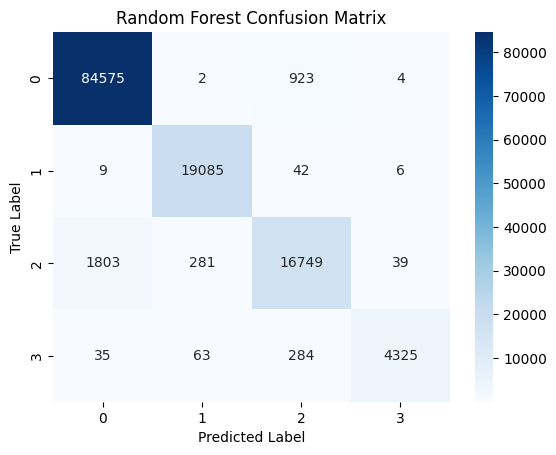

In [32]:
# For Random Forest:
rf_cm = confusion_matrix(y_test, rf_predictions)

# For Random Forest:
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

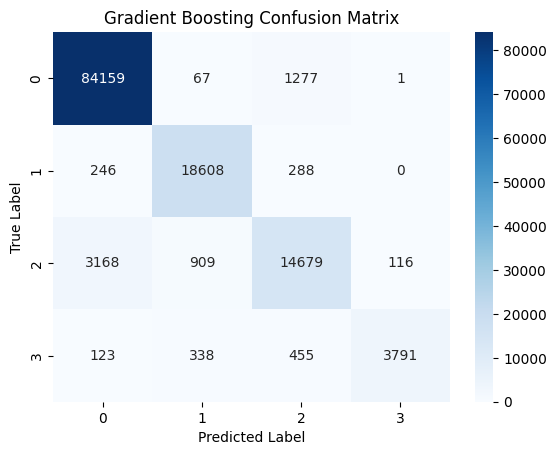

In [33]:
# For Gradient Boosting:
gb_cm = confusion_matrix(y_test, gb_predictions)

# For Gradient Boosting:
sns.heatmap(gb_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [34]:
# For Random Forest:
rf_report = classification_report(y_test, rf_predictions)

print("Random Forest Classification Report:")
print(rf_report)

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     85504
           1       0.98      1.00      0.99     19142
           2       0.93      0.89      0.91     18872
           3       0.99      0.92      0.95      4707

    accuracy                           0.97    128225
   macro avg       0.97      0.95      0.96    128225
weighted avg       0.97      0.97      0.97    128225



In [35]:
# For Gradient Boosting:
gb_report = classification_report(y_test, gb_predictions)

print("\nGradient Boosting Classification Report:")
print(gb_report)


Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     85504
           1       0.93      0.97      0.95     19142
           2       0.88      0.78      0.83     18872
           3       0.97      0.81      0.88      4707

    accuracy                           0.95    128225
   macro avg       0.94      0.88      0.91    128225
weighted avg       0.94      0.95      0.94    128225

